Project 3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')


<Figure size 2000x1000 with 0 Axes>

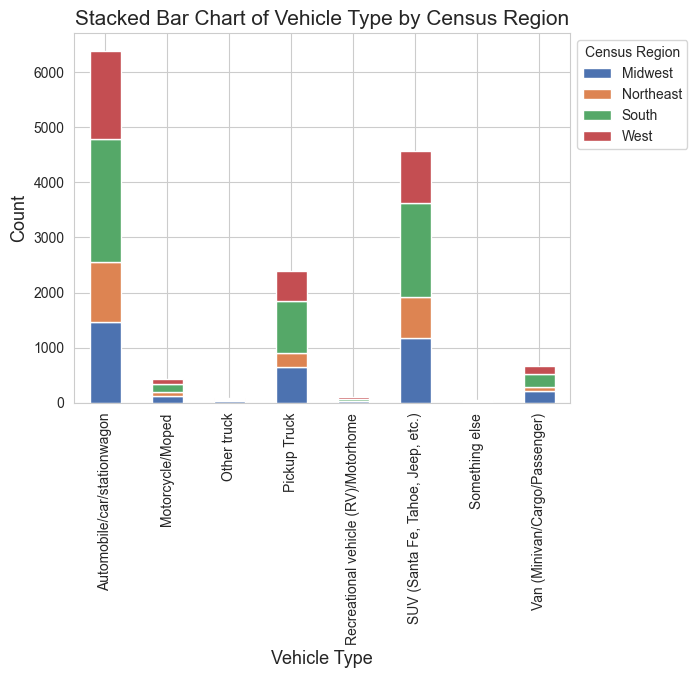

In [3]:
# 1a (i) - Bar Graph
nhts_data = nhts_data.dropna(subset=['vehicle_type'])

data_grouped = nhts_data.groupby(['vehicle_type', 'census_region']).size().unstack(fill_value=0)

plt.figure(figsize=(20,10))
data_grouped.plot(kind='bar', stacked=True)

plt.xlabel('Vehicle Type', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.title('Stacked Bar Chart of Vehicle Type by Census Region', fontsize=15)
plt.xticks(rotation=90)
plt.legend(title='Census Region', bbox_to_anchor=(1,1), loc='upper left')

plt.show()

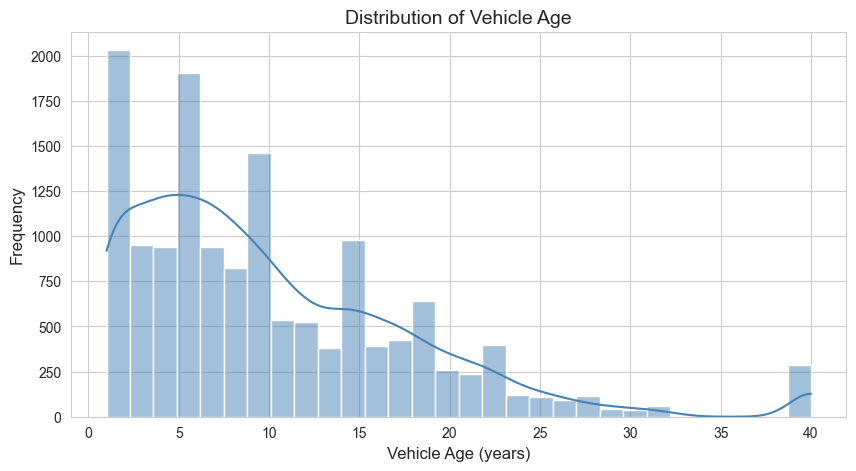

In [4]:
# 1a (ii) - Histogram
plt.figure(figsize=(10,5))
sns.histplot(nhts_data['vehicle_age'], bins=30, kde=True, color='steelblue')

plt.xlabel('Vehicle Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Vehicle Age', fontsize=14)

plt.show()

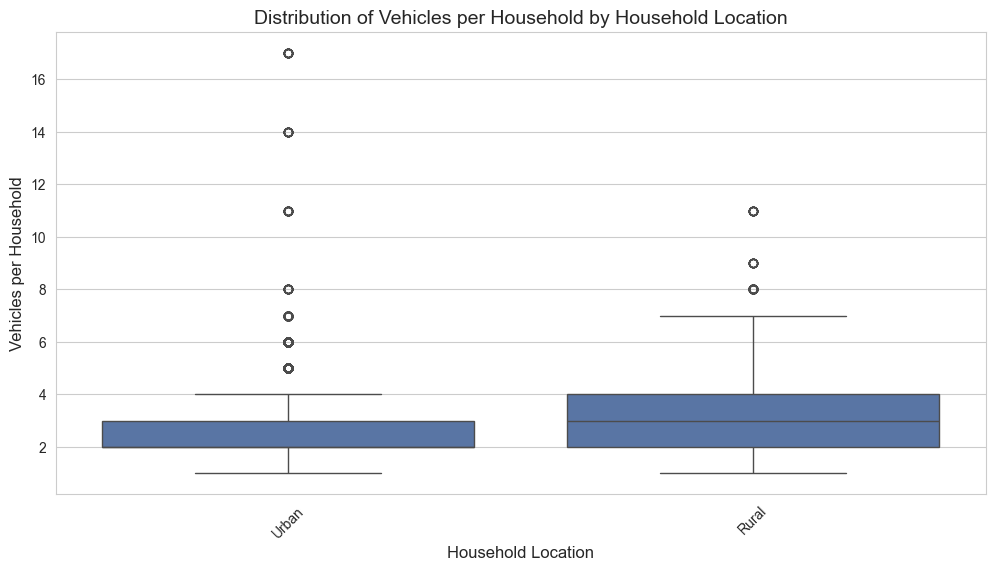

In [5]:
# 1a (iii) - Box plot
plt.figure(figsize=(12,6))
sns.boxplot(data=nhts_data, x='household_location', y='vehicles_per_household')

plt.xlabel('Household Location', fontsize=12)
plt.ylabel('Vehicles per Household', fontsize=12)
plt.title('Distribution of Vehicles per Household by Household Location', fontsize=14)
plt.xticks(rotation=45)

plt.show()

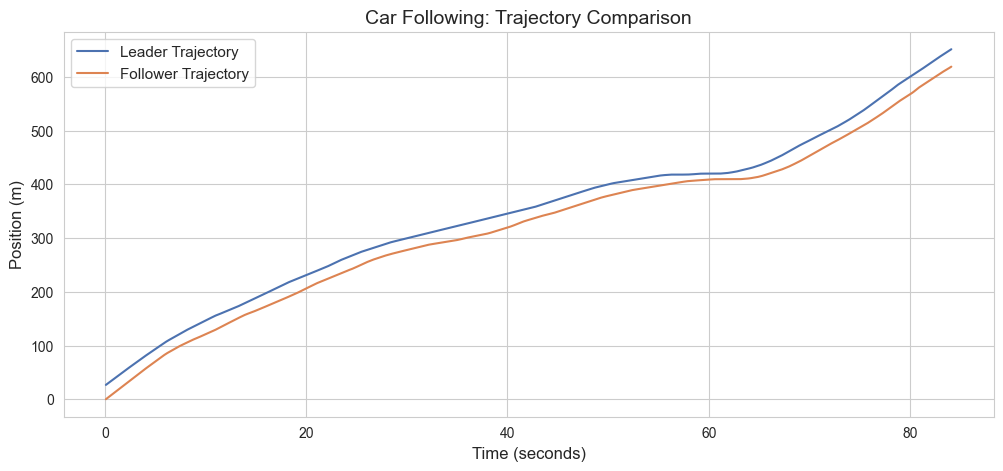

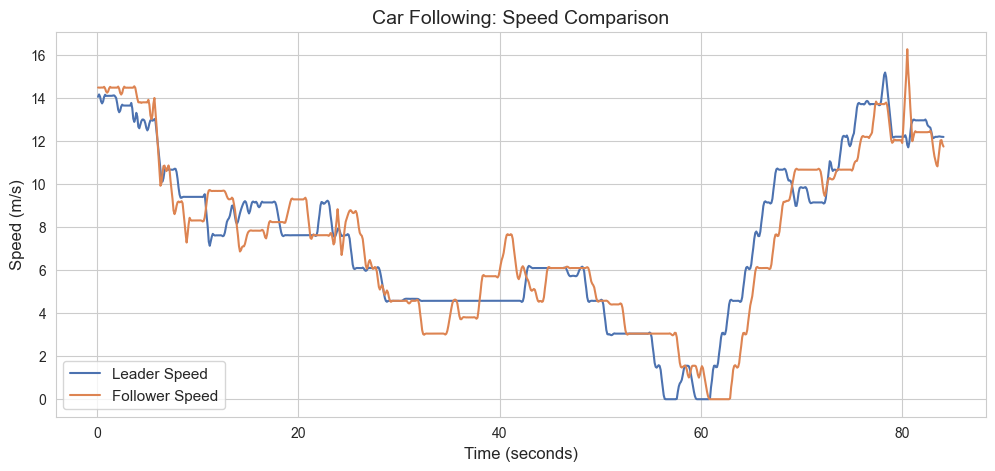

In [6]:
# 1a (iv) - Time-Series plot
trajectory_number = 1

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize=(12,5))

sns.lineplot(x=data_subset['Time'], y=data_subset['leader_position(m)'], label='Leader Trajectory')
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_position(m)'], label='Follower Trajectory')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('Car Following: Trajectory Comparison', fontsize=14)
plt.legend(fontsize=11)

plt.show()

trajectory_number = 1

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize=(12,5))

sns.lineplot(x=data_subset['Time'], y=data_subset['leader_speed(m/s)'], label='Leader Speed')
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_speed(m/s)'], label='Follower Speed')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Car Following: Speed Comparison', fontsize=14)
plt.legend(fontsize=11)

plt.show()

In [7]:
# 1b - NOTHING TO SHOW

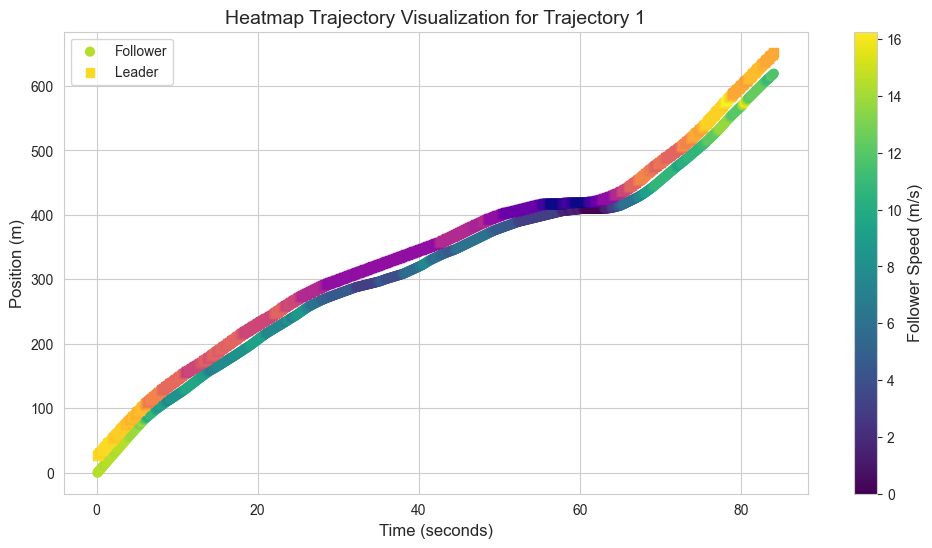

In [8]:
# 1c - Custom scatter plot
trajectory_number = 1

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

plt.figure(figsize=(12, 6))

scatter1 = plt.scatter(
    data_subset['Time'],
    data_subset['follower_position(m)'],
    c=data_subset['follower_speed(m/s)'],
    cmap='viridis',
    s=40,
    label='Follower'
)

scatter2 = plt.scatter(
    data_subset['Time'],
    data_subset['leader_position(m)'],
    c=data_subset['leader_speed(m/s)'],
    cmap='plasma',
    s=40,
    marker='s',
    label='Leader'
)

cbar1 = plt.colorbar(scatter1)
cbar1.set_label('Follower Speed (m/s)', fontsize=12)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title(f'Heatmap Trajectory Visualization for Trajectory {trajectory_number}', fontsize=14)
plt.legend()

plt.show()

In [9]:
# 2a - IDM Simulation
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)

    return acceleration

ngsim_data = pd.read_csv("NGSIM.csv")

traj = ngsim_data[ngsim_data["trajectory_number"] == 1].copy()

leader_position = traj["leader_position(m)"].values
leader_speed = traj["leader_speed(m/s)"].values

follower_position = traj["follower_position(m)"].values
follower_speed = traj["follower_speed(m/s)"].values

time = traj["Time"].values
dt = time[1] - time[0]

v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4

n_steps = len(time)

sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

sim_position[0] = follower_position[0]
sim_speed[0] = follower_speed[0]

for i in range(n_steps - 1):

    s = leader_position[i] - sim_position[i]
    delta_v = sim_speed[i] - leader_speed[i]

    sim_acc[i] = idm_acceleration(sim_speed[i], s, delta_v, v0, s0, T, a_param, b, delta)

    sim_speed[i + 1] = sim_speed[i] + sim_acc[i] * dt
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

Simulation complete!


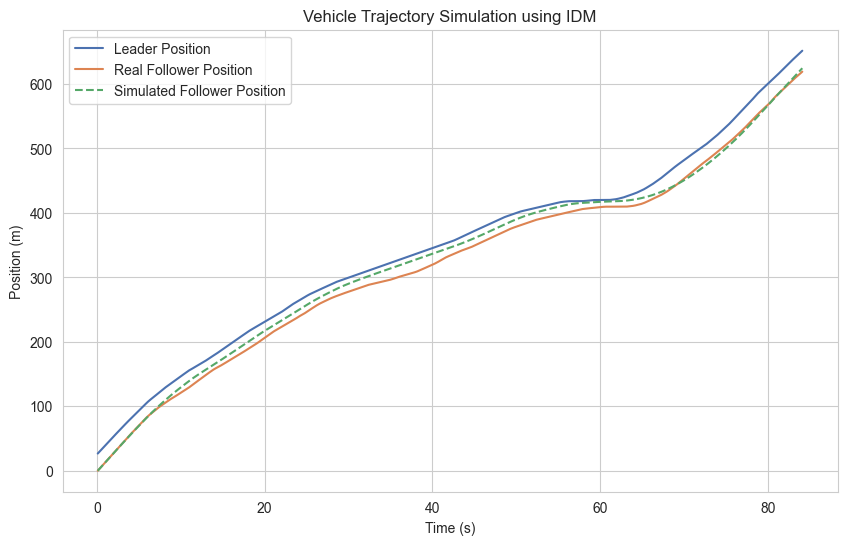

In [10]:
# 2a - Leader vs real follower and simulated follower (trajectory)
plt.figure(figsize=(10,6))

plt.plot(time, leader_position, label="Leader Position")
plt.plot(time, follower_position, label="Real Follower Position")
plt.plot(time, sim_position, label="Simulated Follower Position", linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Vehicle Trajectory Simulation using IDM")
plt.legend()
plt.grid(True)

plt.show()

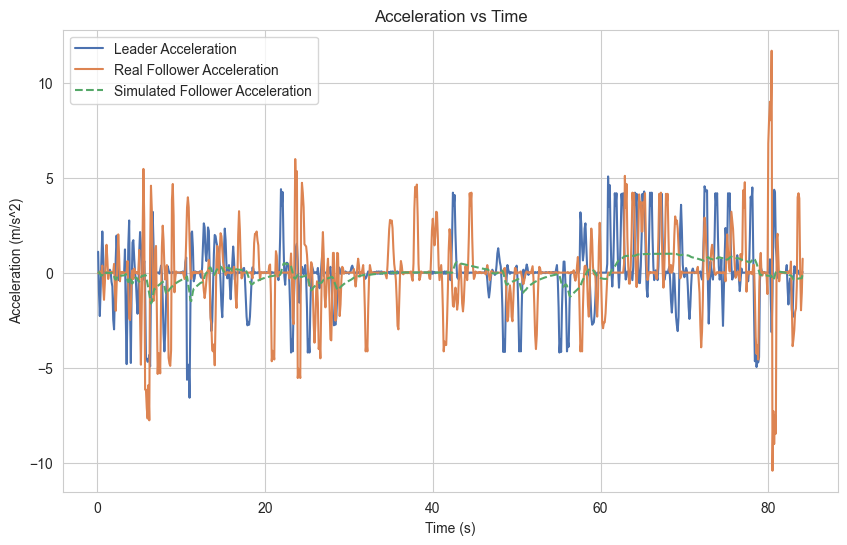

In [11]:
# 2b - Leader vs real follower and simulated follower (acceleleration)
leader_acc = traj["leader_acc(m/s^2)"].values
real_acc = traj["follower_acc(m/s^2)"].values

plt.figure(figsize=(10,6))

plt.plot(time, leader_acc, label="Leader Acceleration")
plt.plot(time, real_acc, label="Real Follower Acceleration")
plt.plot(time, sim_acc, label="Simulated Follower Acceleration", linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Acceleration vs Time")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Time table of work done
time_log = pd.DataFrame({
    'Task': [
        'Bar chart',
        'Histogram',
        'Boxplot',
        'Time-series plot 1',
        'Time-series plot 2',
        'Customized plot',
        'IDM simulation setup',
        'IDM trajectory plot',
        'IDM acceleration comparison plot',
        'Write-up / interpretation'
    ],
    'Minutes Spent (minutes)': [
        12,
        6,
        7,
        8,
        3,
        4,
        8,
        6,
        2,
        3
    ]
})

print(time_log)
print()
print("Total Minutes:", time_log['Minutes Spent (minutes)'].sum())

                               Task  Minutes Spent (minutes)
0                         Bar chart                       12
1                         Histogram                        6
2                           Boxplot                        7
3                Time-series plot 1                        8
4                Time-series plot 2                        3
5                   Customized plot                        4
6              IDM simulation setup                        8
7               IDM trajectory plot                        6
8  IDM acceleration comparison plot                        2
9         Write-up / interpretation                        3

Total Minutes: 59
